# Statistical plots from a table

Almost every plot in `ov.pl` starts from an `AnnData`. That is the right
default for an embedding or a spatial map, but it gets in the way for the
ordinary figures a paper is made of — a bar chart with a test on it, a
histogram, a ridgeline, a regression, a Q-Q plot. Those need a column of
numbers and a column of labels, and nothing else.

This tutorial covers the **table-first layer** of `ov.pl`. Every function here
takes a `pandas.DataFrame` plus column names, or bare arrays, or an `AnnData`
(in which case `.obs` is read) — interchangeably.

| Function | Draws |
| --- | --- |
| `ov.pl.barplot` | Bars of a summary statistic, error bars, optional raw points |
| `ov.pl.stripplot` | Every observation, jittered, over a summary crossbar |
| `ov.pl.violinplot` | Kernel densities, optionally split by a two-level factor |
| `ov.pl.stackplot` | Stacked composition — counts or proportions |
| `ov.pl.pieplot` / `donutplot` | Composition as a wedge chart |
| `ov.pl.lollipopplot` | Ranked values as stem-and-dot |
| `ov.pl.slopeplot` | One line per subject between conditions, with a paired test |
| `ov.pl.histplot` | Histograms — count, density, probability, stacked, filled |
| `ov.pl.kdeplot` | Kernel density in 1-D or 2-D |
| `ov.pl.ridgeplot` | Overlapping densities, one per group |
| `ov.pl.qqplot` | Q-Q against a distribution or a second sample, with λ<sub>GC</sub> |
| `ov.pl.scatterplot` | y against x, with categorical or continuous colour |
| `ov.pl.lineplot` | Trends with replicate aggregation and an error band |
| `ov.pl.regplot` | Scatter with a linear, polynomial or LOWESS fit |
| `ov.pl.compare_groups` | The tests, as a tidy table |
| `ov.pl.add_stat_annotation` | Significance brackets, stacked so they never collide |
| `ov.pl.as_plotdata` / `accepts_frame` | Let the `AnnData` plots take a table too |

The names carry a `...plot` suffix on purpose. `ov.pl.violin` still takes an
`AnnData` and knows about genes and layers; `ov.pl.violinplot` takes a frame.
Nothing existing changes.

**The tests are not decoration.** Every plot that can annotate a comparison
routes through `ov.pl.compare_groups`, and hands back the same table it drew
from — so the stars on the figure and the numbers in the text cannot drift
apart.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. The data

`pbmc68k_reduced` is a 700-cell subset of the 10x 68k PBMC reference. It is a
good fit here because everything is real and already computed: `bulk_labels`
are the **FACS-sorted** populations (ground truth, not clustering),
`phase` / `S_score` / `G2M_score` come from cell-cycle scoring, and the QC
metrics and a differential-expression run are stored alongside.

In [2]:
adata = sc.datasets.pbmc68k_reduced()
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Everything below works directly on `adata` — the plots read `.obs`. But to
make the point that no container is needed, we pull the metadata out into a
plain DataFrame and add two marker genes as columns.

`ov.pl.as_plotdata` is the accessor that does the second part: it resolves a
name against metadata columns *or* features, dense or sparse, whatever the
container. Section 9 comes back to it.

In [3]:
view = ov.pl.as_plotdata(adata)
cells = adata.obs.copy()
for gene in ["CD3D", "NKG7"]:
    cells[gene] = view.values(gene)
cells["population"] = cells["bulk_labels"].astype(str)
cells.head(3)

,bulk_labels,n_genes,percent_mito,n_counts,S_score,G2M_score,phase,louvain,CD3D,NKG7,population
index,,,,,,,,,,,
AAAGCCTGGCTAAC-1,CD14+ Monocyte,1003,0.023856,2557.0,-0.119160,-0.816889,G1,1,-0.608,-0.387,CD14+ Monocyte
AAATTCGATGCACA-1,Dendritic,1080,0.027458,2695.0,0.067026,-0.889498,S,1,-0.608,-0.387,Dendritic
AACACGTGGTCTTT-1,CD56+ NK,1228,0.016819,3389.0,-0.147977,-0.941749,G1,3,-0.227,4.525,CD56+ NK


In [4]:
big = cells["population"].value_counts()
keep = big[big >= 30].index
main = cells[cells["population"].isin(keep)].copy()
print(f"{len(main)} of {len(cells)} cells in the {len(keep)} populations with n >= 30")
big

660 of 700 cells in the 7 populations with n >= 30


population
Dendritic                       240
CD14+ Monocyte                  129
CD19+ B                          95
CD4+/CD25 T Reg                  68
CD8+ Cytotoxic T                 54
CD8+/CD45RA+ Naive Cytotoxic     43
CD56+ NK                         31
CD4+/CD45RO+ Memory              19
CD34+                            13
CD4+/CD45RA+/CD25- Naive T        8
Name: count, dtype: int64

## 2. Composition — `pieplot`, `donutplot`, `stackplot`

`pieplot` counts the rows of each category. `donutplot` is the same with the
middle cut out, which leaves room for the total — worth having, because a
composition without an absolute size is easy to over-read.

Ten categories with three of them under 2% is where a pie chart falls apart.
Two arguments fix it, and both say what they did: `other_threshold` merges the
small wedges into one and prints which ones, and `legend=True` moves the names
off the wedges entirely.

pieplot: merged 3 categories below 3% into 'other': CD34+, CD4+/CD45RA+/CD25- Naive T, CD4+/CD45RO+ Memory


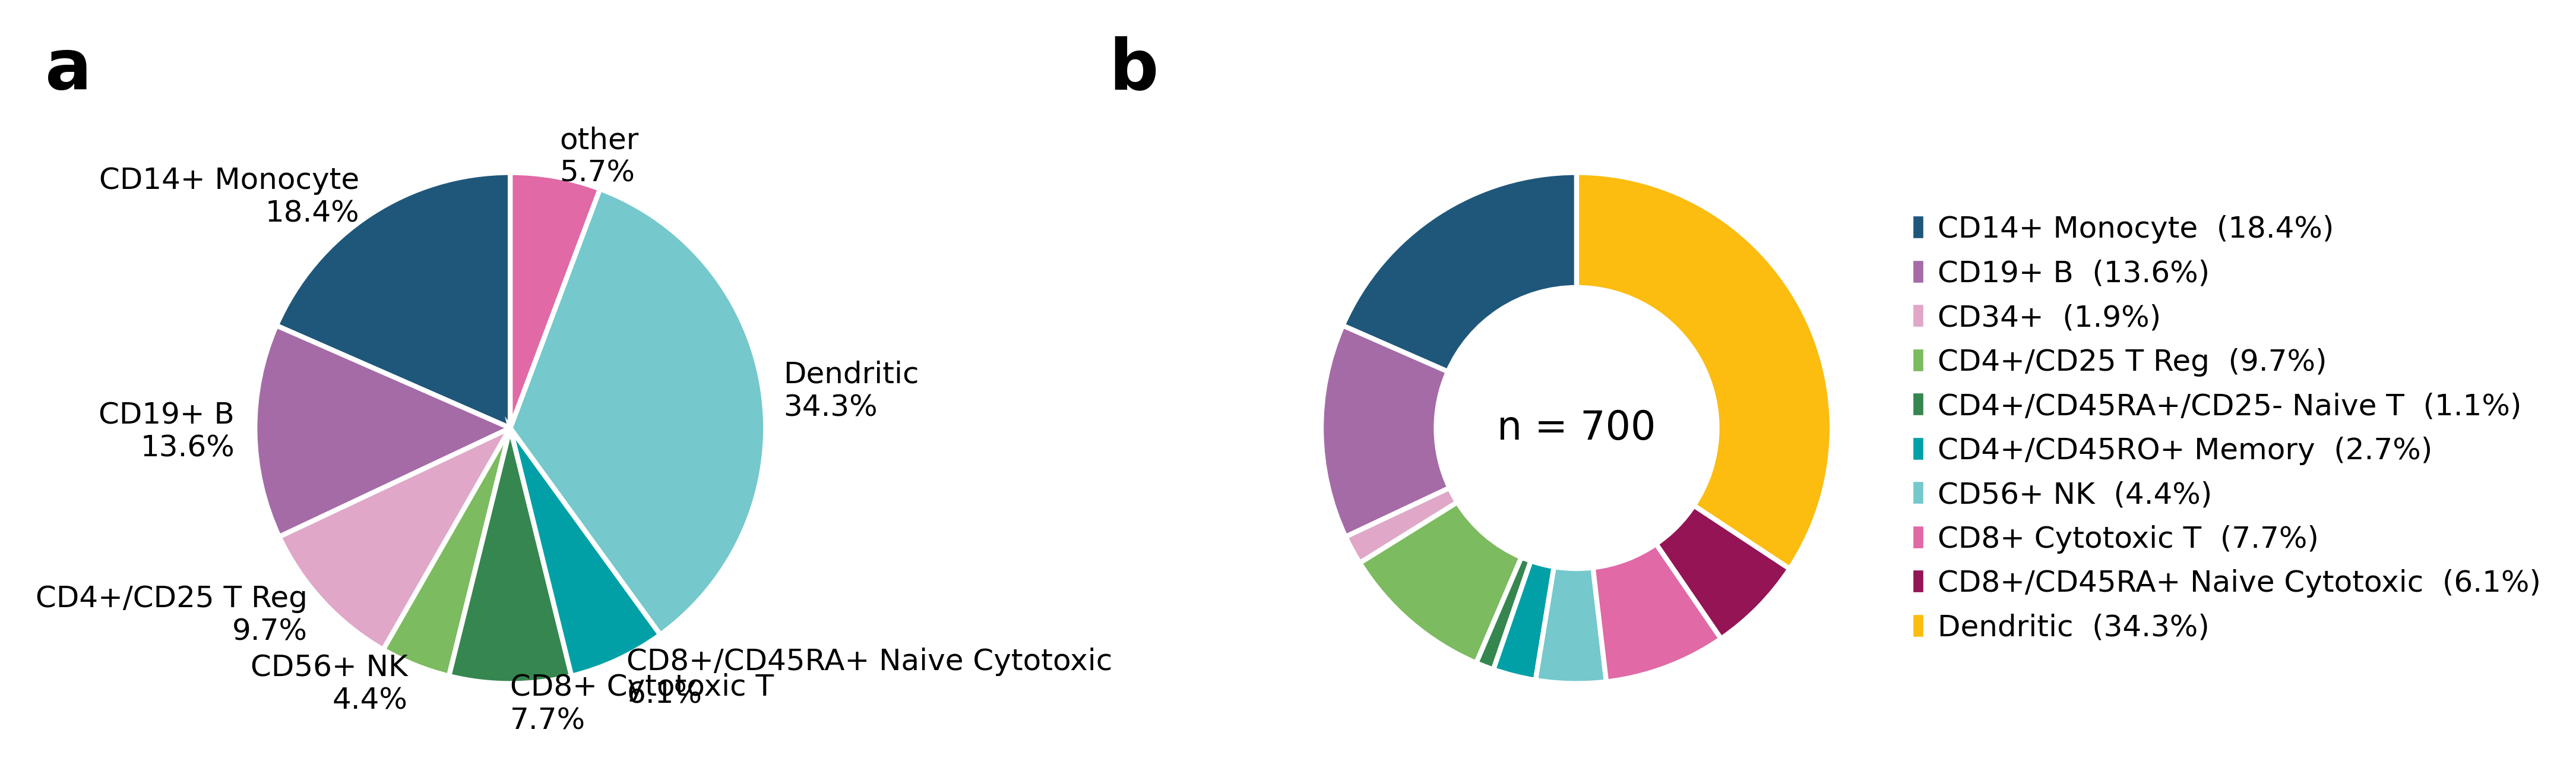

In [5]:
fig, axes = ov.pl.multipanel((1, 2), width=180, height=75)
ov.pl.pieplot(cells, "population", ax=axes["a"], fontsize=6,
              other_threshold=0.03, label_style="percent")
ov.pl.donutplot(cells, "population", ax=axes["b"], fontsize=6, legend=True)
plt.show()

`stackplot` answers the two-factor question: what is each population made
of? Here that is the cell-cycle phase, so the bars say which sorted
populations were proliferating when the sample was taken.

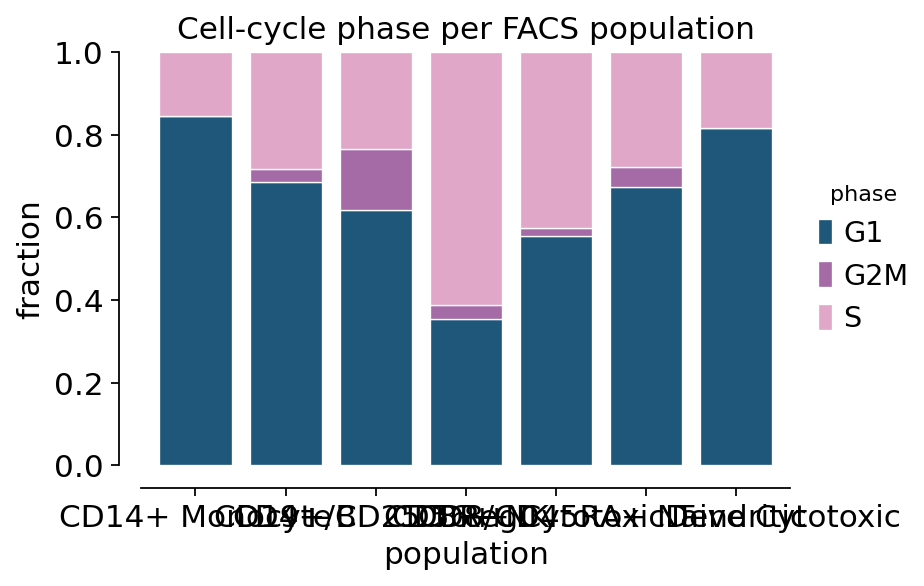

In [6]:
ax = ov.pl.stackplot(main, "population", hue="phase", figsize=(5.2, 3.4),
                     rotation=45, title="Cell-cycle phase per FACS population")
plt.show()

In [7]:
ax, matrix = ov.pl.stackplot(main, "population", hue="phase",
                             figsize=(5.2, 3.2), rotation=45,
                             return_stats=True)
plt.close()
matrix.round(3)

hue,G1,G2M,S
x,,,
CD14+ Monocyte,0.845,0.000,0.155
CD19+ B,0.684,0.032,0.284
CD4+/CD25 T Reg,0.618,0.147,0.235
CD56+ NK,0.355,0.032,0.613
CD8+ Cytotoxic T,0.556,0.019,0.426
CD8+/CD45RA+ Naive Cytotoxic,0.674,0.047,0.279
Dendritic,0.817,0.000,0.183


## 3. Comparing groups — `violinplot`, `stripplot`, `barplot`

The three ways of showing the same comparison, in increasing order of how much
of the data you can see. All of them take `test=` and draw the brackets from
the result.

`'auto'` means Mann-Whitney U for the pairs and a Kruskal-Wallis omnibus over
all of them — no normality assumed, which is the honest default for expression
data. P values are Holm-corrected across the pairs, because every pair is
being tested.

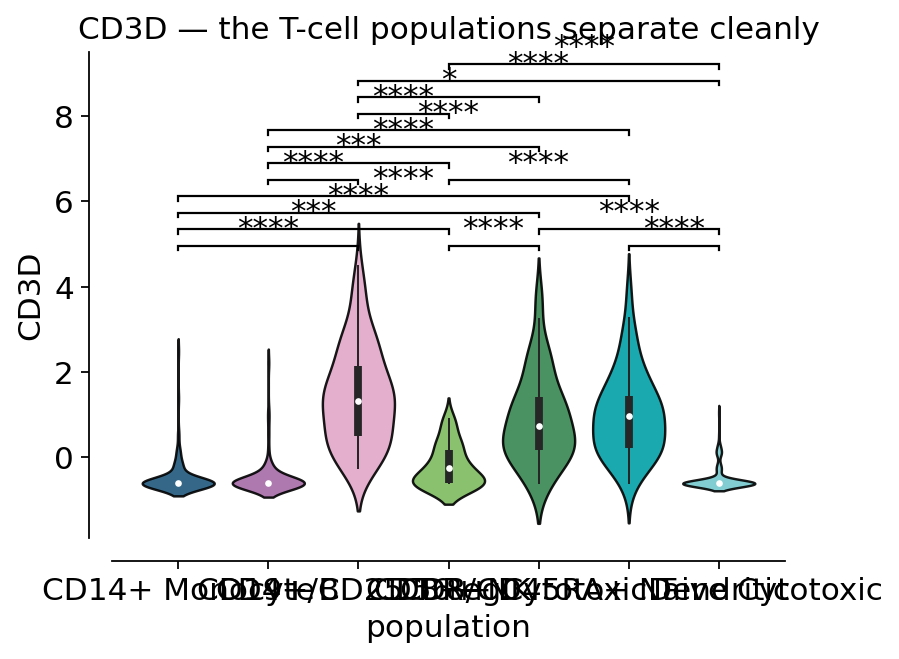

In [8]:
ax = ov.pl.violinplot(main, "population", "CD3D", test="auto",
                      hide_ns=True, rotation=45, figsize=(5.4, 4.0),
                      title="CD3D — the T-cell populations separate cleanly")
plt.show()

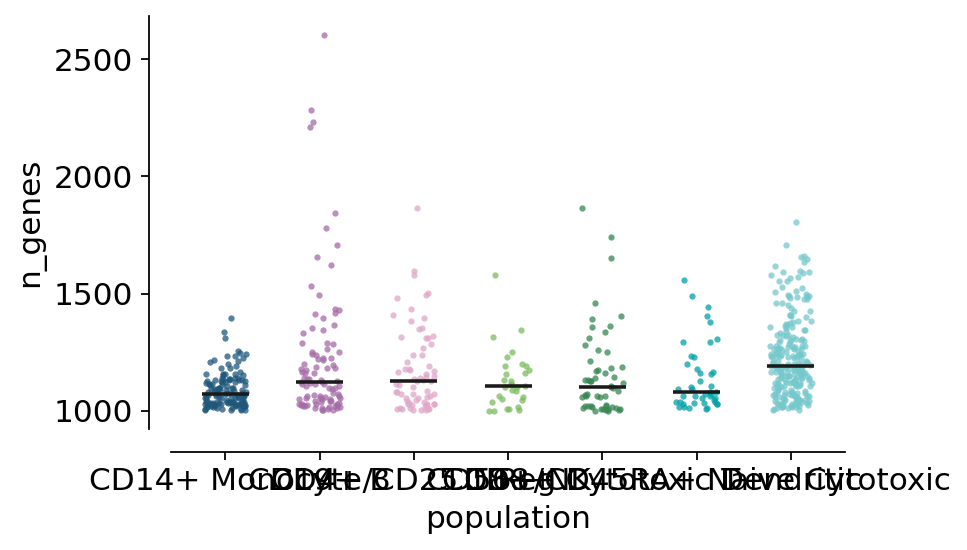

In [9]:
ax = ov.pl.stripplot(main, "population", "n_genes", summary="median",
                     rotation=45, figsize=(5.4, 3.4), jitter=0.22, size=8)
plt.show()

A bar chart hides n. `dots=True` puts the observations back on top, which
is the difference between a bar built on 240 cells and one built on 31.

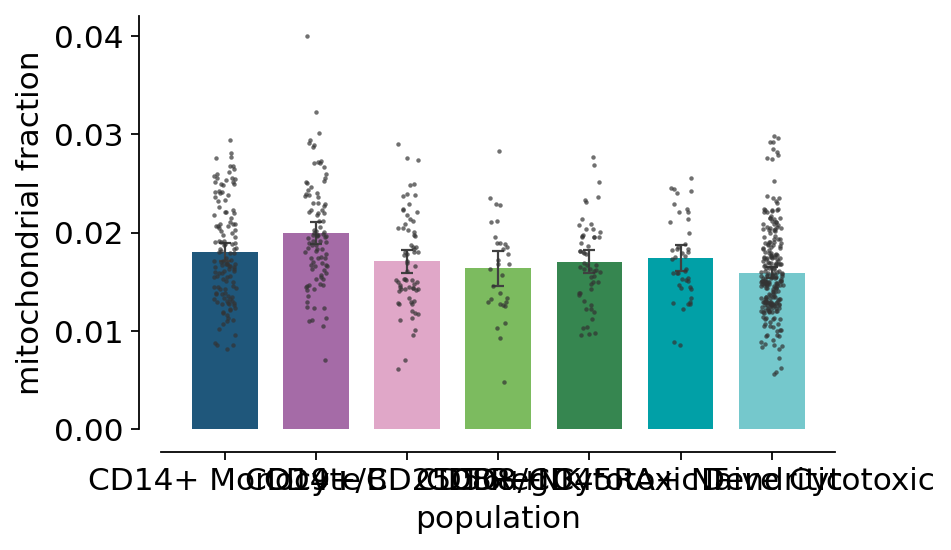

In [10]:
ax = ov.pl.barplot(main, "population", "percent_mito", errorbar="ci",
                   dots=True, dot_size=4, rotation=45, figsize=(5.4, 3.4),
                   ylabel="mitochondrial fraction")
plt.show()

The numbers behind the stars come back as a tidy table — the same one the
brackets were drawn from.

In [11]:
res = ov.pl.compare_groups(main, "CD3D", "population")
res.sort_values("pvalue_corrected").head(6).round(4)

,group1,group2,n1,n2,statistic,pvalue,pvalue_corrected,test
0,*,*,660,7,410.3739,0.0,0.0,Kruskal-Wallis
15,CD4+/CD25 T Reg,Dendritic,68,240,16061.5000,0.0,0.0,Mann-Whitney U
20,CD8+ Cytotoxic T,Dendritic,54,240,12149.0000,0.0,0.0,Mann-Whitney U
21,CD8+/CD45RA+ Naive Cytotoxic,Dendritic,43,240,9962.5000,0.0,0.0,Mann-Whitney U
2,CD14+ Monocyte,CD4+/CD25 T Reg,129,68,200.5000,0.0,0.0,Mann-Whitney U
7,CD19+ B,CD4+/CD25 T Reg,95,68,147.0000,0.0,0.0,Mann-Whitney U


`add_stat_annotation` also works on an axes you drew yourself, and on a
subset of the comparisons. Ask for the pairs you actually care about and the
correction stops paying for the ones you do not.

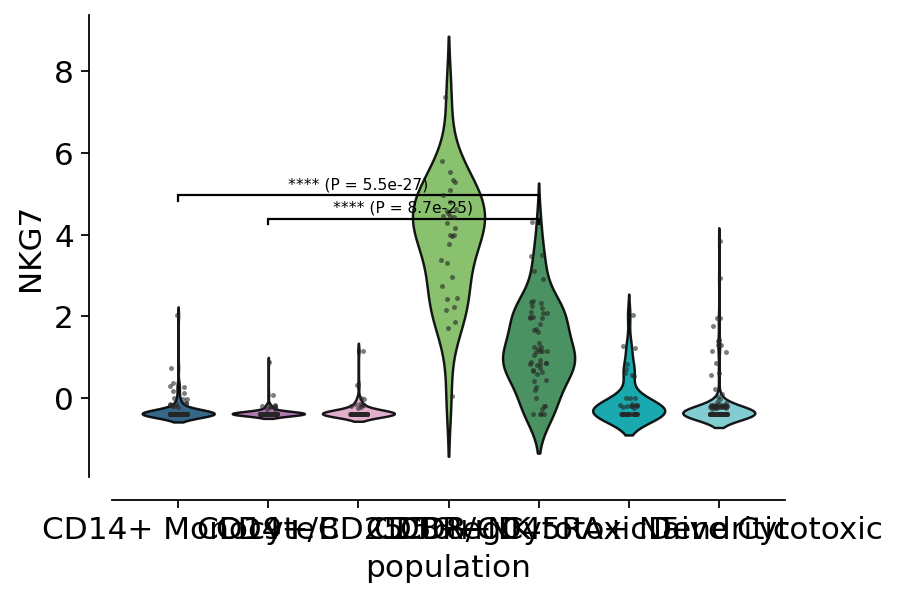

In [12]:
pairs = [("CD8+ Cytotoxic T", "CD19+ B"), ("CD8+ Cytotoxic T", "CD14+ Monocyte")]
ax = ov.pl.violinplot(main, "population", "NKG7", rotation=45,
                      figsize=(5.4, 3.8), inner="point")
ov.pl.add_stat_annotation(ax, main, "NKG7", "population", pairs=pairs,
                          style="full", fontsize=7)
plt.show()

With a second factor, `split=True` mirrors two levels inside one violin —
half the width for twice the comparison.

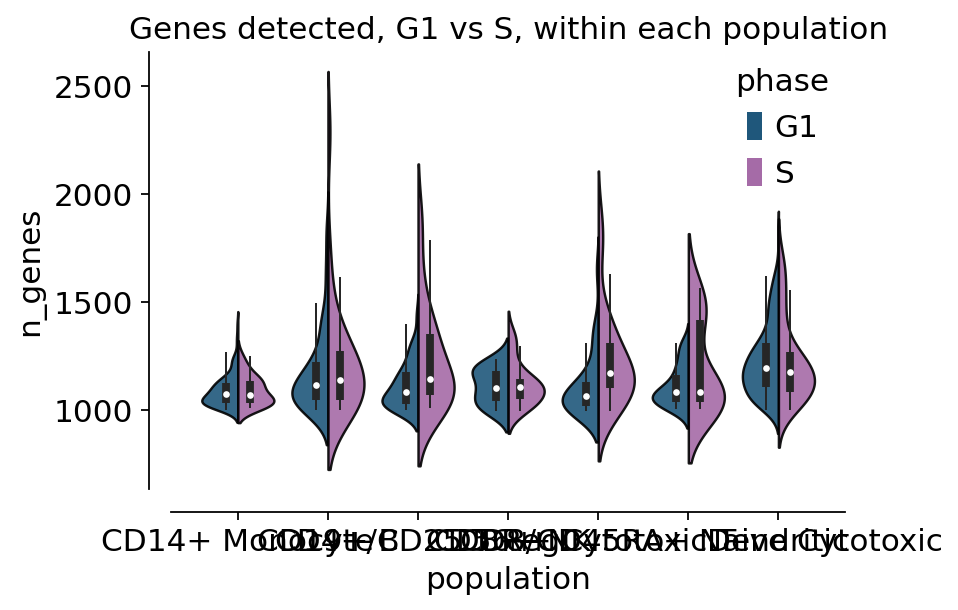

In [13]:
cycling = main[main["phase"].isin(["G1", "S"])]
ax = ov.pl.violinplot(cycling, "population", "n_genes", hue="phase",
                      split=True, rotation=45, figsize=(5.4, 3.6),
                      title="Genes detected, G1 vs S, within each population")
plt.show()

## 4. Distributions — `histplot`, `kdeplot`, `ridgeplot`

`stat='density'` makes groups of different size comparable; `multiple='fill'`
turns the same histogram into "what is each bin made of".

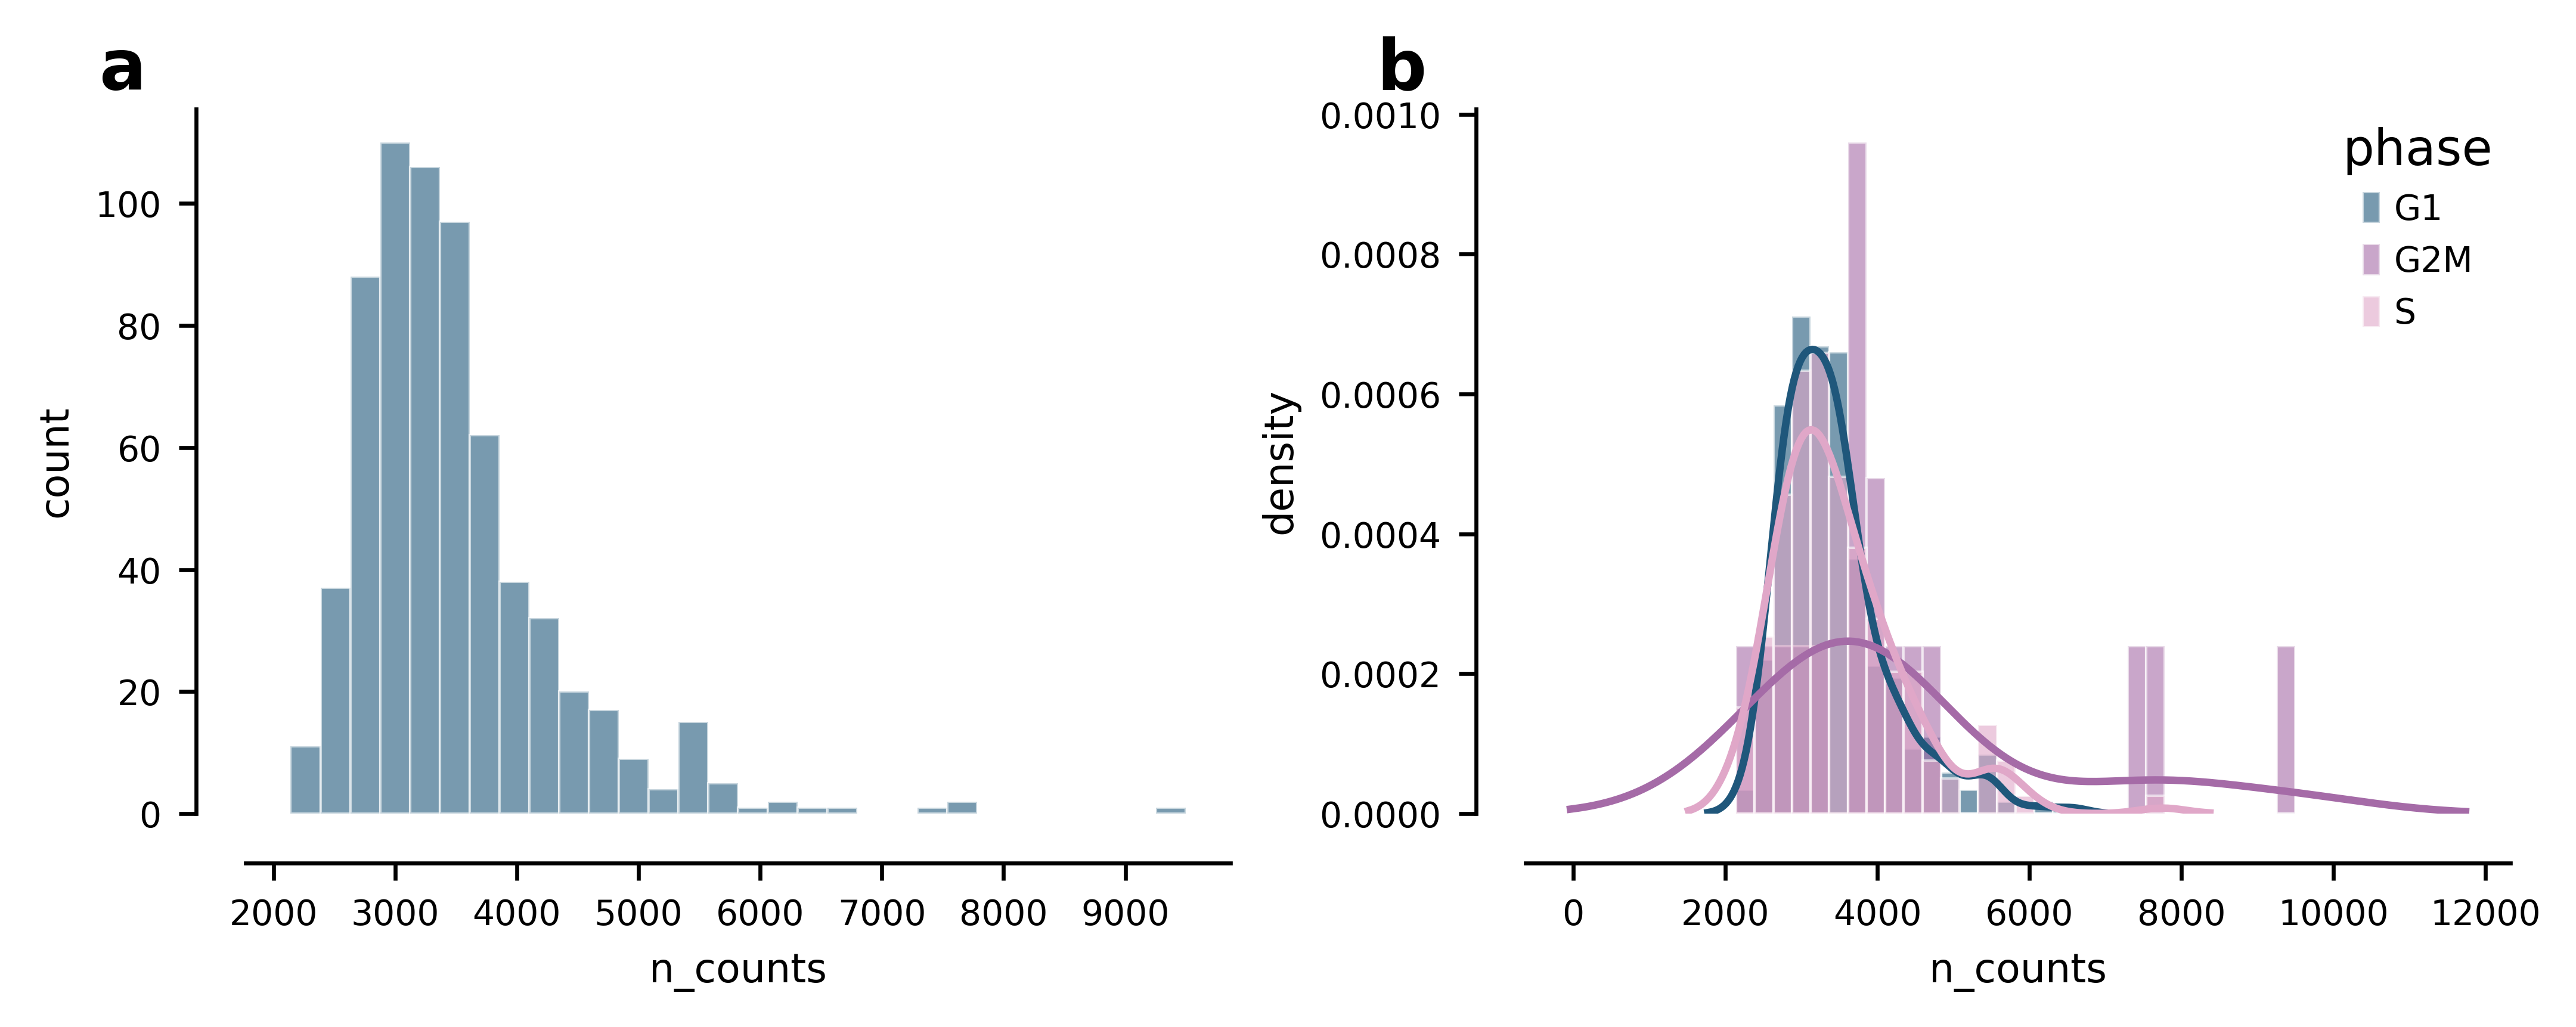

In [14]:
fig, axes = ov.pl.multipanel((1, 2), width=180, height=70)
ov.pl.histplot(main, "n_counts", bins=30, ax=axes["a"], fontsize=7)
ov.pl.histplot(main, "n_counts", bins=30, hue="phase", stat="density",
               kde=True, ax=axes["b"], fontsize=7)
plt.show()

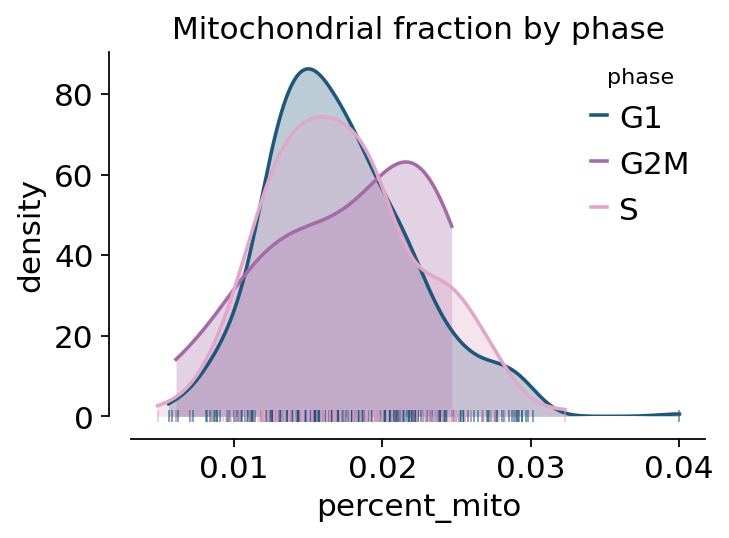

In [15]:
ax = ov.pl.kdeplot(main, "percent_mito", hue="phase", fill=True, rug=True,
                   figsize=(4.6, 3.0), cut=0,
                   title="Mitochondrial fraction by phase")
plt.show()

The density behind `kdeplot`, `ridgeplot` and `violinplot` is available on
its own as `ov.pl.kde_curve`. Worth knowing for one argument in particular:
`cut` extends the grid past the data by that many **kernel bandwidths**, the
meaning it has in seaborn and R. `cut=0` stops exactly at the data, which is
what a bounded quantity needs — a mitochondrial *fraction* has no density
below zero.

In [16]:
values = main["percent_mito"].to_numpy()
for cut in (0, 2, 6):
    grid, _ = ov.pl.kde_curve(values, cut=cut)
    print(f"cut={cut}: support {grid.min():+.4f} .. {grid.max():.4f}")
grid, _ = ov.pl.kde_curve(values, cut=6, clip=(0, None))
print(f"cut=6, clip=(0, None): support {grid.min():+.4f} .. {grid.max():.4f}")

cut=0: support +0.0048 .. 0.0400
cut=2: support +0.0021 .. 0.0427
cut=6: support -0.0032 .. 0.0481
cut=6, clip=(0, None): support +0.0000 .. 0.0481


In [17]:
grid, density = ov.pl.kde_curve(values, cut=0, gridsize=400)
print("integrates to", round(float(np.trapz(density, grid)), 4))
print("modal percent_mito:", round(float(grid[density.argmax()]), 4))

integrates to 0.9969
modal percent_mito: 0.0151


A ridgeline is the right plot for a dozen distributions at once — ordered
by the statistic you care about, and coloured by it too, so the ranking is
readable without going back to the axis.

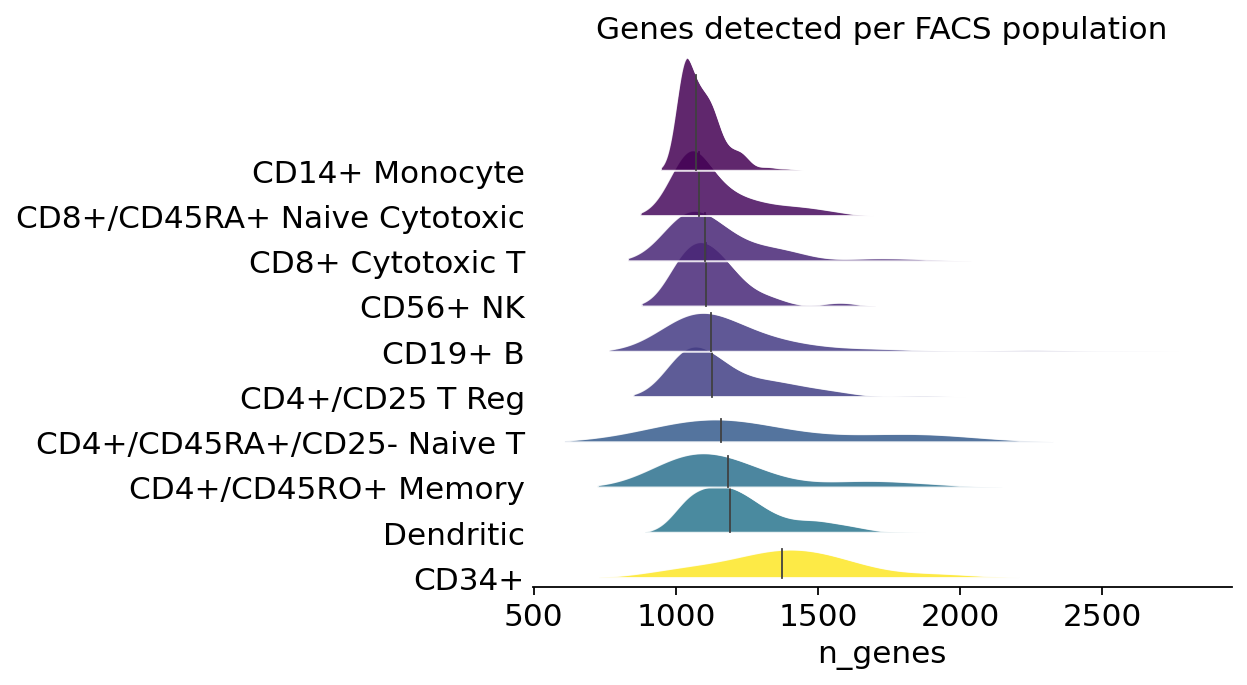

In [18]:
ax = ov.pl.ridgeplot(cells, "n_genes", "population", order="median",
                     color_by="median", cmap="viridis",
                     quantile_lines=[0.5], figsize=(5.6, 4.4),
                     title="Genes detected per FACS population")
plt.show()

## 5. Relationships — `scatterplot`, `regplot`, `lineplot`

The QC scatter everyone draws. `density=True` colours each point by the local
point density, which is the fix for a cloud where 700 identical dots hide the
shape.

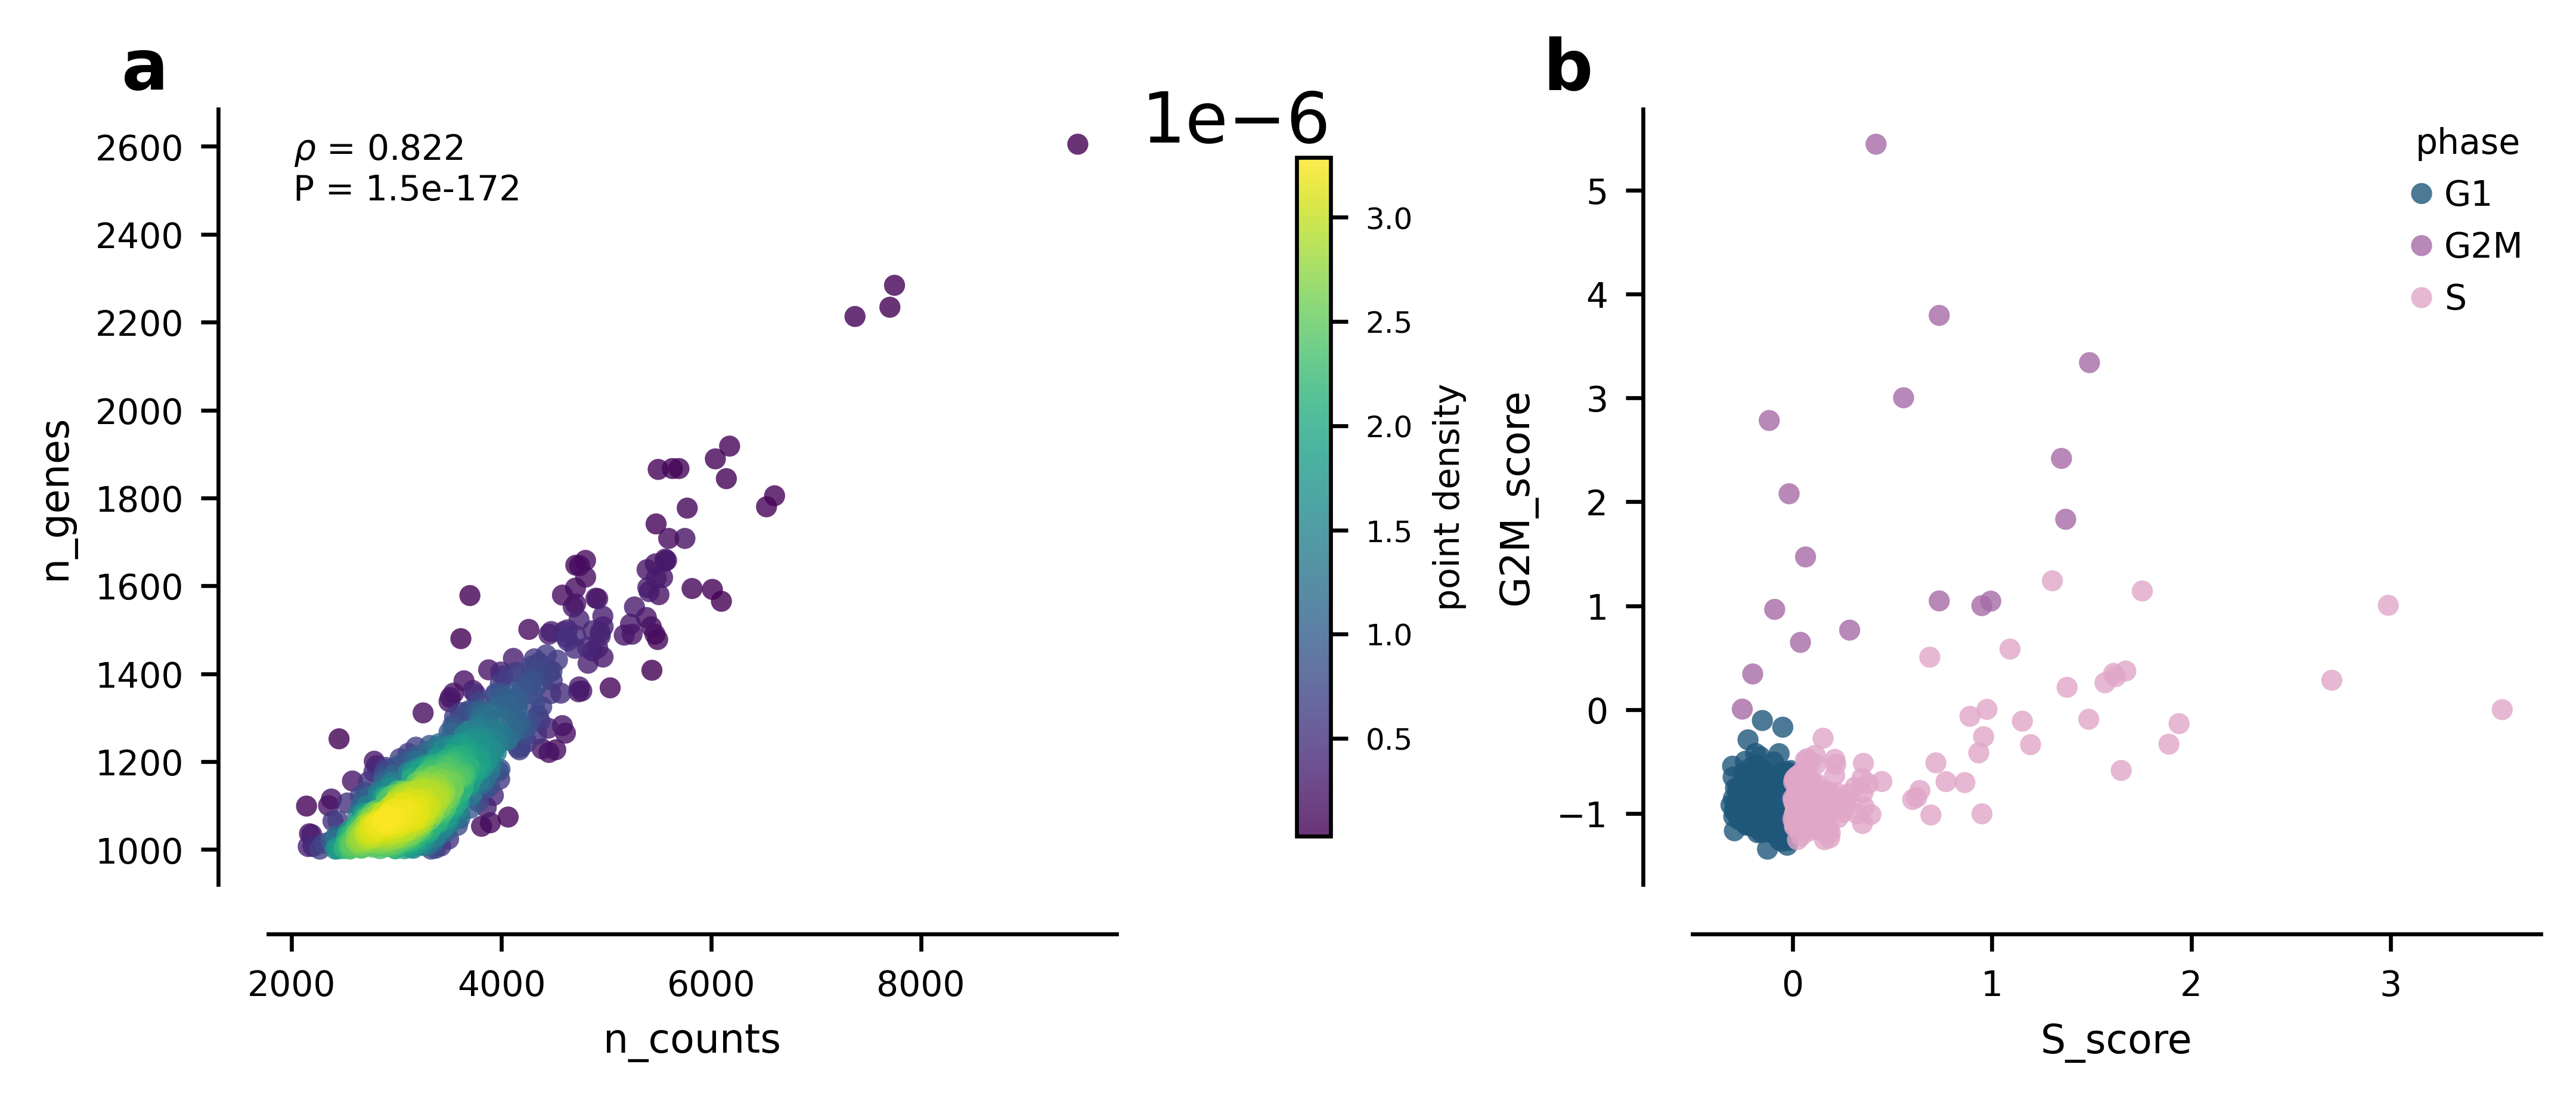

In [19]:
fig, axes = ov.pl.multipanel((1, 2), width=180, height=75)
ov.pl.scatterplot(cells, "n_counts", "n_genes", density=True,
                  corr="spearman", ax=axes["a"], fontsize=7)
ov.pl.scatterplot(cells, "S_score", "G2M_score", hue="phase",
                  ax=axes["b"], fontsize=7)
plt.show()

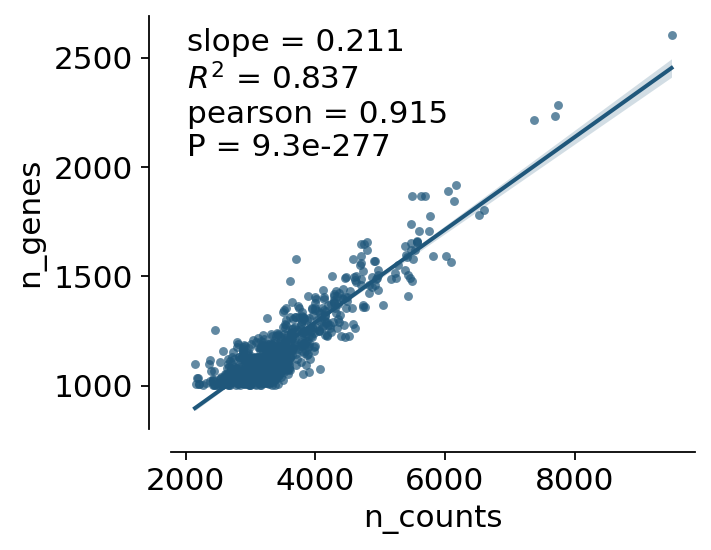

{'slope': 0.2115, 'intercept': 444.2605, 'r_squared': 0.8366, 'correlation': 0.9146, 'pvalue': 0.0}


In [20]:
ax, fit = ov.pl.regplot(cells, "n_counts", "n_genes", figsize=(4.2, 3.4),
                        return_stats=True)
plt.show()
print({k: round(v, 4) for k, v in fit[None].items() if k != "n"})

A non-parametric fit when a straight line is the wrong model. LOWESS gets
no confidence band here on purpose — an honest one needs a bootstrap that this
function does not run, and drawing a band from nothing would be worse than
drawing none.

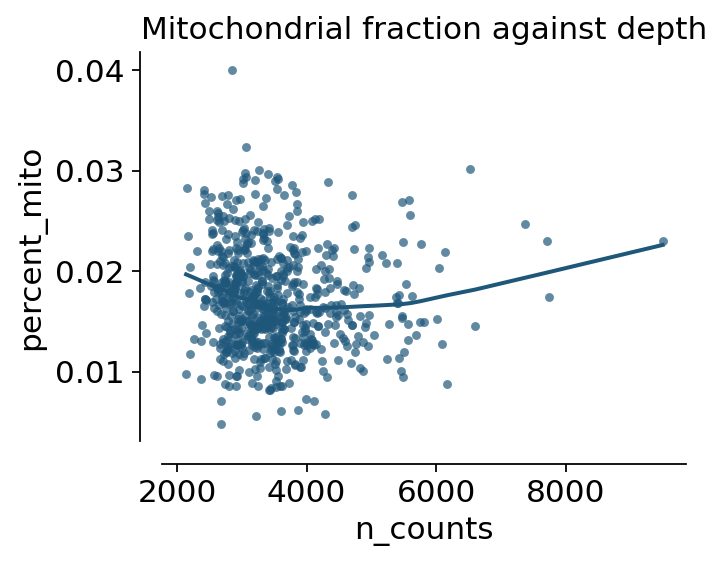

In [21]:
ax = ov.pl.regplot(cells, "n_counts", "percent_mito", fit="lowess",
                   lowess_frac=0.5, figsize=(4.2, 3.2), annotate=False,
                   title="Mitochondrial fraction against depth")
plt.show()

`lineplot` aggregates repeated measurements at each x and draws the
spread. There is no time course in this dataset, so we make a real gradient
instead: cells binned along PC1, which orders them from myeloid to lymphoid.

In [22]:
trend = cells[["CD3D", "NKG7", "n_genes"]].copy()
trend["pc1_bin"] = pd.qcut(adata.obsm["X_pca"][:, 0], 10, labels=False)
long = trend.melt(id_vars="pc1_bin", value_vars=["CD3D", "NKG7"],
                  var_name="gene", value_name="expression")
long.head(3)

,pc1_bin,gene,expression
0,0,CD3D,-0.608
1,0,CD3D,-0.608
2,9,CD3D,-0.227


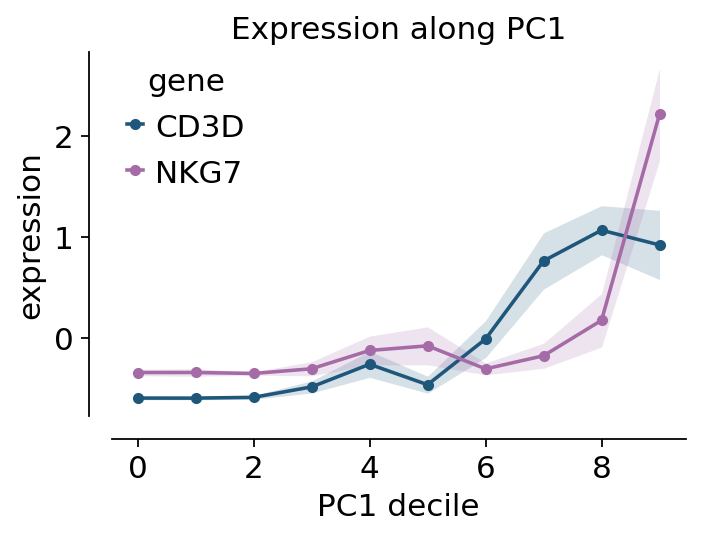

In [23]:
ax = ov.pl.lineplot(long, "pc1_bin", "expression", hue="gene",
                    errorbar="ci", markers=True, figsize=(4.6, 3.0),
                    xlabel="PC1 decile", title="Expression along PC1")
plt.show()

## 6. Q-Q plots — `qqplot`

Two different jobs, one function.

First: are the residuals of that regression normal? The confidence band comes
from the Beta order statistics, so a point outside it is genuinely unusual
rather than just at the end of the sample.

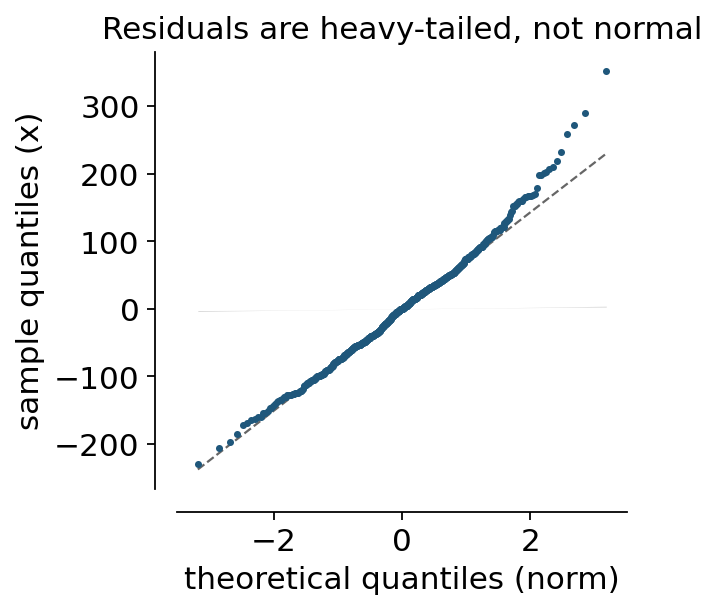

In [24]:
slope, intercept = np.polyfit(cells["n_counts"], cells["n_genes"], 1)
residuals = cells["n_genes"] - (slope * cells["n_counts"] + intercept)
ax = ov.pl.qqplot(residuals, dist="norm", figsize=(3.6, 3.6),
                  title="Residuals are heavy-tailed, not normal")
plt.show()

Second: the P values of a differential-expression run against the uniform
null, on the −log10 scale. We run a real Wilcoxon test of CD19+ B against the
rest — the P values stored in this dataset came from a logistic-regression
ranking and carry none.

The reported λ<sub>GC</sub> is the genomic inflation factor — the median
observed χ² over the median expected. For a real marker test it should be far
above 1, and it is; the same plot on a null comparison would sit on the
diagonal.

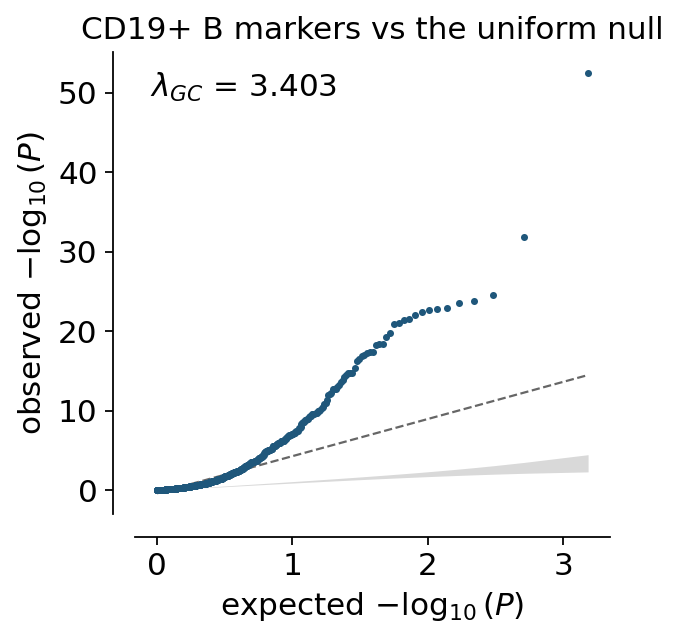

lambda_GC = 3.4 over 765 genes


In [25]:
sc.tl.rank_genes_groups(adata, "bulk_labels", groups=["CD19+ B"],
                        reference="rest", method="wilcoxon", key_added="de")
de = sc.get.rank_genes_groups_df(adata, group="CD19+ B", key="de")
ax, qq = ov.pl.qqplot(de["pvals"].to_numpy(), dist="uniform", log=True,
                      figsize=(3.8, 3.8), return_stats=True,
                      title="CD19+ B markers vs the uniform null")
plt.show()
print(f"lambda_GC = {qq['lambda_gc']:.1f} over {qq['n']} genes")

## 7. Ranked effects — `lollipopplot`

A bar chart of thirty ranked values is mostly ink. A lollipop is the same
information with the eye guided to the dot.

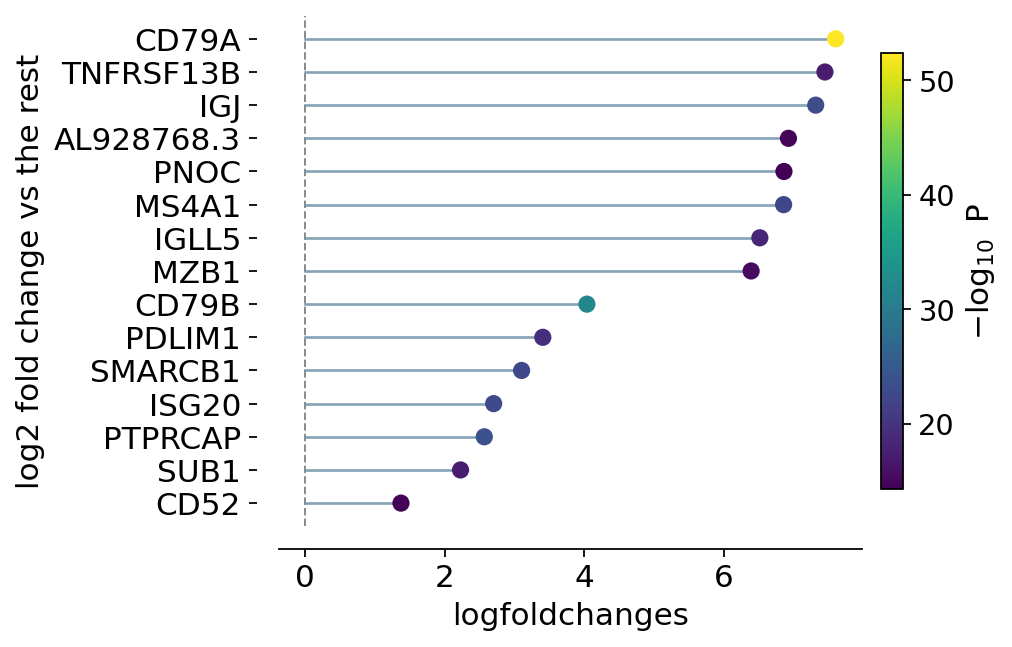

In [26]:
markers = de.head(15).copy()
markers["neglog10P"] = -np.log10(markers["pvals"].clip(lower=1e-300))
ax = ov.pl.lollipopplot(markers, "names", "logfoldchanges", reference=0,
                        color_by=markers["neglog10P"], cmap="viridis",
                        colorbar_label="$-\\log_{10}$ P", figsize=(5.0, 4.2),
                        xlabel="log2 fold change vs the rest")
plt.show()

## 8. Paired change — `slopeplot`

A cell in S phase has more RNA, so more genes should be detected. That is a
**paired** question: every population contributes a G1 value and an S value,
and the comparison has to stay inside the population. Pooling all the cells
would confound it with composition — the populations differ in depth far more
than the phases do.

In [27]:
paired = (main[main["phase"].isin(["G1", "S"])]
          .groupby(["population", "phase"], observed=True)["n_genes"]
          .mean().reset_index())
complete = paired["population"].value_counts()
paired = paired[paired["population"].isin(complete[complete == 2].index)]
paired.head(4)

,population,phase,n_genes
0,CD14+ Monocyte,G1,1090.238532
1,CD14+ Monocyte,S,1090.200000
2,CD19+ B,G1,1176.015385
3,CD19+ B,S,1220.037037


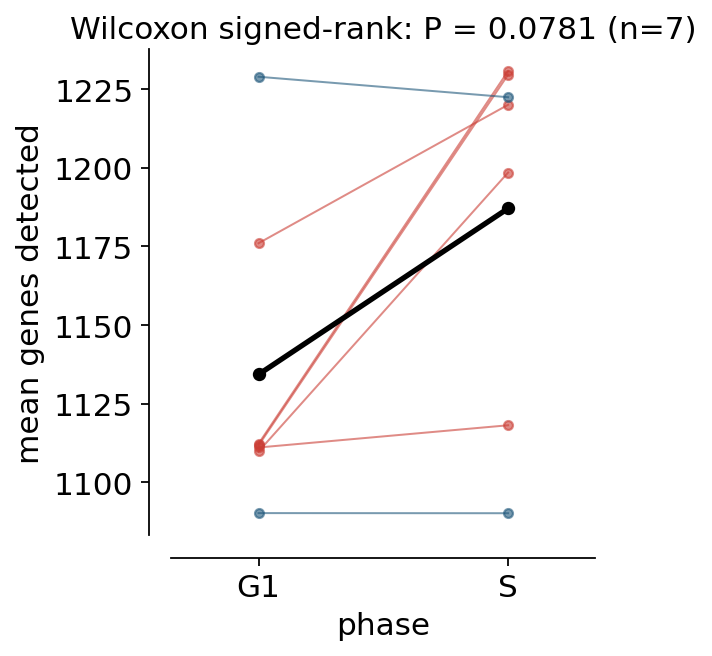

Wilcoxon signed-rank: P = 0.0781 across 7 populations


In [28]:
ax, out = ov.pl.slopeplot(paired, "phase", "n_genes", subject="population",
                          order=["G1", "S"], test="wilcoxon",
                          figsize=(3.4, 4.0), ylabel="mean genes detected",
                          return_stats=True)
plt.show()
print(f"{out['test']}: P = {out['pvalue']:.4f} across {out['n_complete']} populations")

Five of the seven populations move up and the mean rises by about 50
genes, but at n = 7 the signed-rank test gives P = 0.08 — a trend, not a
result. That is the point of the plot rather than a failure of it: a bar
chart of all 683 cells pooled would have produced a confident-looking
difference that was really about which populations happened to be
cycling. The slope chart shows you the seven pairs the claim actually
rests on.

## 9. Not tied to `AnnData` — `as_plotdata` and `accepts_frame`

Everything above took a DataFrame. The same calls take an `AnnData` — its
`.obs` is read — and bare arrays. All three give the same answer.

In [29]:
subset = adata[adata.obs.index.isin(main.index)]
a = ov.pl.compare_groups(main, "CD3D", "bulk_labels", omnibus=False)
b = ov.pl.compare_groups(subset, "CD3D", "bulk_labels", omnibus=False)
c = ov.pl.compare_groups(value=main["CD3D"].to_numpy(),
                         group=main["bulk_labels"].to_numpy(), omnibus=False)
print([round(float(t["pvalue"].sum()), 12) for t in (a, b, c)])

[3.353452050185, 3.353452050185, 3.353452050185]


Note what `b` did: `CD3D` is **not** a column of `adata.obs`, it is a gene. The
resolver checks metadata first and features second, so a gene name works
anywhere a column name does — `ov.pl.violinplot(adata, 'louvain', 'CD3D')`
needs no manual extraction.

The accessor doing that is `ov.pl.as_plotdata`: one `values()` call, whatever
the container, dense or sparse.

In [30]:
view = ov.pl.as_plotdata(adata)
print(view, "| is an", type(view).__name__, isinstance(view, ov.pl.PlotData))
print("from .obs   :", view.values("n_genes")[:3])
print("from .X     :", np.round(view.values("HES4")[:3], 3))
print("embedding   :", view.embedding("umap").shape)

PlotData(700 obs, 8 metadata columns, 765 features) | is an PlotData True
from .obs   : [1003 1080 1228]
from .X     : [-0.326  1.171 -0.326]
embedding   : (700, 2)


In [31]:
table = ov.pl.as_plotdata(cells)
print(table)
print("same accessor:", np.round(table.values("n_genes")[:3], 3))

PlotData(700 obs, 11 metadata columns, 7 features)
same accessor: [1003 1080 1228]


`as_plotdata` binds the accessor to one object. When you just want the
numbers, `ov.pl.get_values` is the same resolver as a plain function — and it
is the single implementation every plot in `ov.pl` now goes through, so a name
resolves identically wherever you type it.

In [32]:
print("gene from .X       :", np.round(ov.pl.get_values(adata, "CD3D")[:4], 3))
print("column from .obs   :", ov.pl.get_values(adata, "n_genes")[:4])
print("column of a frame  :", np.round(ov.pl.get_values(cells, "CD3D")[:4], 3))

gene from .X       : [-0.608 -0.608 -0.227  1.148]
column from .obs   : [1003 1080 1228 1007]
column of a frame  : [-0.608 -0.608 -0.227  1.148]


Three rules are worth knowing, because they are the ones that used to differ
between call sites:

1. **Metadata wins.** A name that is both an `.obs` column and a gene resolves
   to the column.
2. `layer=` reads `.layers[layer]`; combining it with `use_raw=True` is an
   error rather than a silent preference.
3. `use_raw=None` (the default) reads `.X` and falls back to `.raw` **only**
   for names missing from `.var_names` — the state highly-variable-gene
   subsetting leaves behind. This deliberately differs from scanpy's plotting
   default, which prefers `.raw` whenever it exists; pass `use_raw=True` for
   that behaviour.

In [33]:
try:
    ov.pl.get_values(adata, "CD3D", layer="counts", use_raw=True)
except ValueError as err:
    print("refused:", err)
try:
    ov.pl.get_values(adata, "CD3DD")
except KeyError as err:
    print("unknown:", err)

refused: Give either `layer=` or `use_raw=True`, not both — `.raw` has no layers.
unknown: "'CD3DD' is neither a metadata column nor a feature of this object. Did you mean: CD3D, CD63, CD53?"


`ov.pl.get_matrix` is the multi-name version. It reads each underlying matrix
once instead of once per name, which is what a dot plot over fifty genes
needs.

In [34]:
block = ov.pl.get_matrix(adata, ["CD3D", "NKG7", "n_genes"])
print(block.shape, block.dtype)
pd.DataFrame(block, columns=["CD3D", "NKG7", "n_genes"]).head(3).round(3)

(700, 3) float64


,CD3D,NKG7,n_genes
0,-0.608,-0.387,1003.0
1,-0.608,-0.387,1080.0
2,-0.227,4.525,1228.0


And for the existing `AnnData`-shaped plots, `ov.pl.accepts_frame` lets
them take a table. Two are already converted, as proof: `ov.pl.cellproportion`
and `ov.pl.cellstackarea` now accept a DataFrame wherever they accepted an
`AnnData`.

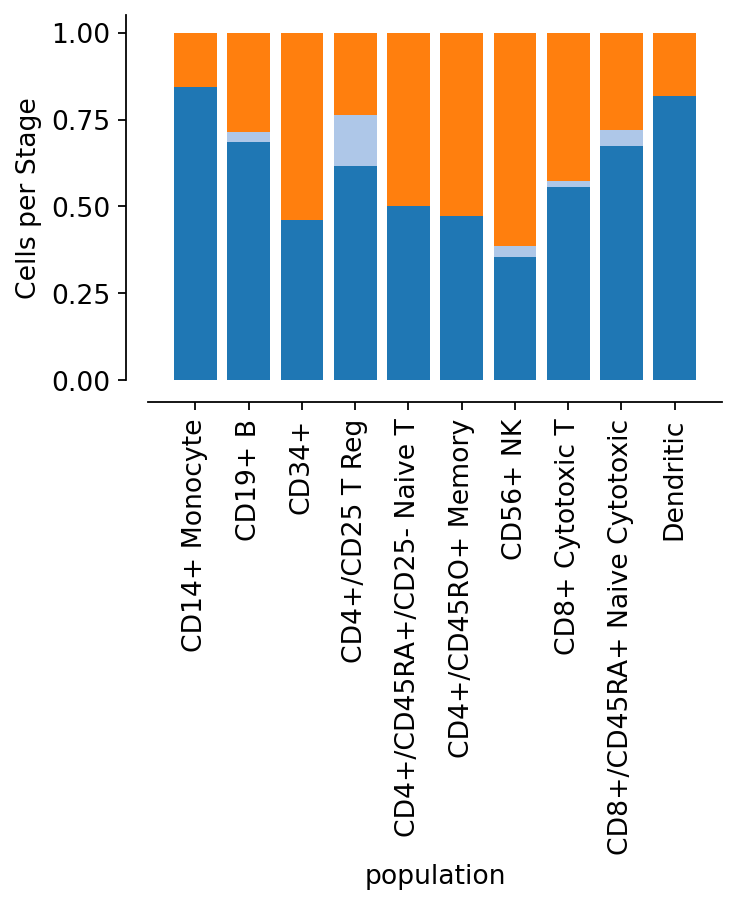

In [35]:
fig, ax = plt.subplots(figsize=(4.6, 3.0))
ov.pl.cellproportion(cells, celltype_clusters="phase",
                     groupby="population", ax=ax)
plt.show()

In [36]:
print("the caller's frame is untouched:", cells["population"].dtype)

the caller's frame is untouched: object


Applying it to your own function really is one line — here it is, run rather
than quoted.

In [37]:
@ov.pl.accepts_frame
def population_sizes(adata, groupby):
    return adata.obs[groupby].value_counts()

print(population_sizes(cells, "phase").to_dict())          # a DataFrame
print(population_sizes(adata, "phase").to_dict())          # an AnnData

{'G1': 501, 'S': 182, 'G2M': 17}
{'G1': 501, 'S': 182, 'G2M': 17}


The wrapper hands over an `ov.pl.ObsView` — a metadata-only view, **not** a
fake `AnnData`. That distinction is the point: a function that needs expression
values fails immediately and says what to do, instead of quietly plotting an
empty array.

In [38]:
view = ov.pl.ObsView(cells)
print(view, "| shape", view.shape)
try:
    view.X
except AttributeError as err:
    print("refused:", err)

ObsView(700 rows x 11 columns) | shape (700, 0)
refused: This plot was given a DataFrame, which has no 'X'. Pass an AnnData if you need expression values — or use ov.pl.as_plotdata() to see what a table can supply.


In [39]:
ov.pl.format_pvalue(1.7e-9), ov.pl.format_pvalue(0.031, "full"), ov.pl.format_pvalue(0.4)

('****', '* (P = 0.031)', 'ns')

Applying it to your own function is one line:

```python
from omicverse.pl import accepts_frame

@accepts_frame
def my_plot(adata, groupby):
    counts = adata.obs[groupby].value_counts()
    ...
```

The wrapper hands a metadata-only view to the function. It deliberately is
*not* a fake `AnnData`: reaching for `.X` on it raises immediately, naming the
problem, instead of failing three lines later on an empty array.

```python
ov.pl.ObsView(df).X
# AttributeError: This plot was given a DataFrame, which has no 'X'.
#                 Pass an AnnData if you need expression values ...
```

## Summary

| Question | Call |
| --- | --- |
| Is this group different? | `ov.pl.violinplot(df, 'group', 'value', test='auto')` |
| By how much, with what P? | `ov.pl.compare_groups(df, 'value', 'group')` |
| Brackets on a plot I drew | `ov.pl.add_stat_annotation(ax, df, 'value', 'group')` |
| What is each sample made of? | `ov.pl.stackplot(df, 'sample', hue='cell_type')` |
| Twelve distributions at once | `ov.pl.ridgeplot(df, 'value', 'group')` |
| Does y track x? | `ov.pl.regplot(df, 'x', 'y')` |
| Are these P values inflated? | `ov.pl.qqplot(p, dist='uniform', log=True)` |
| Did each subject change? | `ov.pl.slopeplot(df, 'time', 'value', subject='id', test='wilcoxon')` |
| Make my AnnData plot take a table | `@ov.pl.accepts_frame` |

Every one of them also accepts an `AnnData` or bare arrays in place of the
DataFrame. That is the whole point.